In [ ]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SequentialFeatureSelector, RFE
from sklearn.metrics import accuracy_score

In [ ]:
df = pd.read_csv("/content/winequality-red.csv")
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


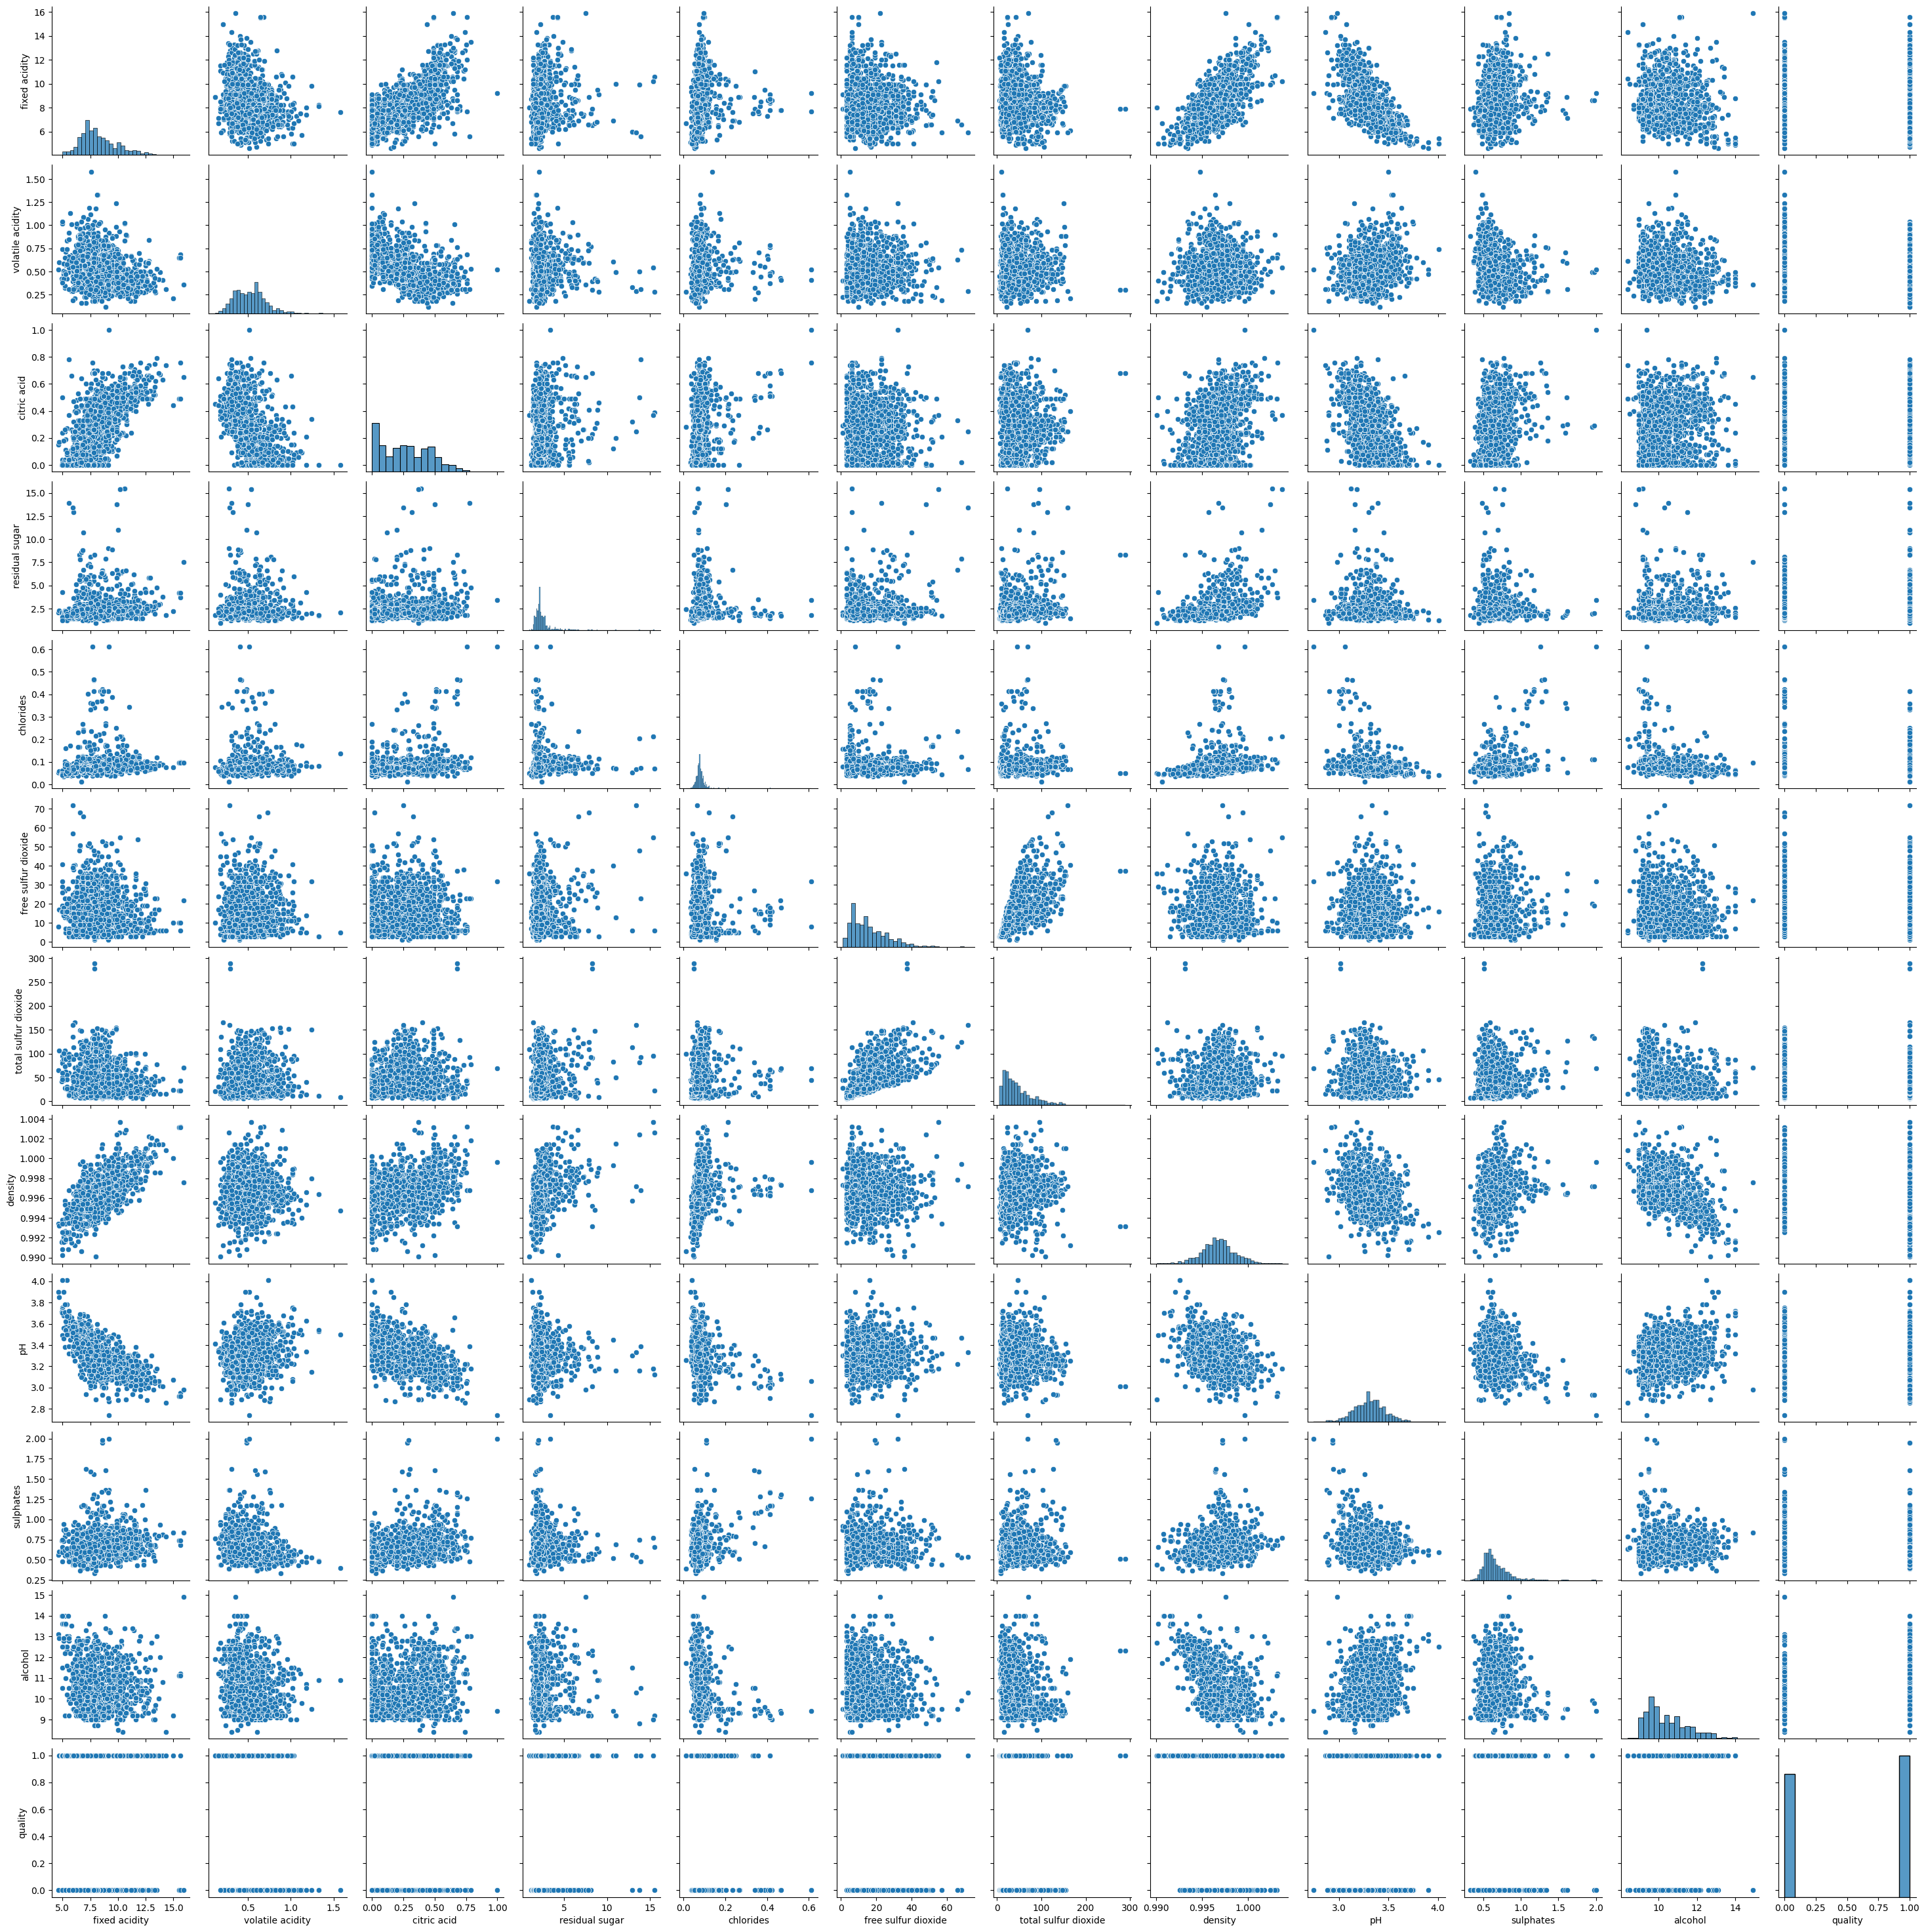

In [ ]:
sb.pairplot(df)

<Axes: >

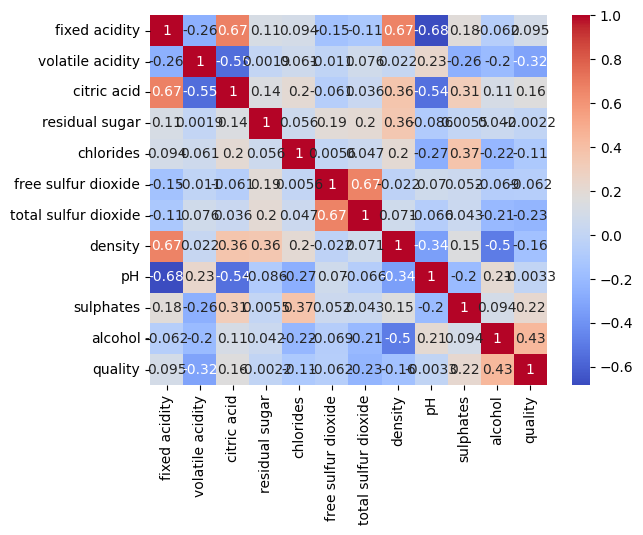

In [ ]:
corr_data = df.corr()
sb.heatmap(corr_data, annot=True, cmap="coolwarm")

In [ ]:
df["quality"] = df["quality"].apply(lambda x: 1 if x >= 6 else 0)

In [ ]:
X = df.drop("quality", axis=1)
y = df["quality"]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
model = LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif
fs = SelectKBest(score_func = f_classif, k = 5)
fs.fit(X_train, y_train)
selected_features = X.columns[fs.get_support()]
print("Selected Features:", selected_features)

Selected Features: Index(['volatile acidity', 'total sulfur dioxide', 'density', 'sulphates',
       'alcohol'],
      dtype='object')


In [ ]:
forward_selector = SequentialFeatureSelector(model, n_features_to_select=5, direction="forward")
forward_selector.fit(X_train, y_train)
selected_features_forward = X.columns[forward_selector.get_support()]
print("Selected Features (Forward Selection):", selected_features_forward)

Selected Features (Forward Selection): Index(['volatile acidity', 'free sulfur dioxide', 'total sulfur dioxide',
       'density', 'alcohol'],
      dtype='object')


In [ ]:
backward_selector = SequentialFeatureSelector(model, n_features_to_select=5, direction="backward")
backward_selector.fit(X_train, y_train)
selected_features_backward = X.columns[backward_selector.get_support()]
print("Selected Features (Backward Selection):", selected_features_backward)

Selected Features (Backward Selection): Index(['volatile acidity', 'chlorides', 'free sulfur dioxide',
       'total sulfur dioxide', 'alcohol'],
      dtype='object')


In [ ]:
rfe_selector = RFE(model, n_features_to_select=5)
rfe_selector.fit(X_train, y_train)
selected_features_rfe = X.columns[rfe_selector.support_]
print("Selected Features (RFE):", selected_features_rfe)

Selected Features (RFE): Index(['volatile acidity', 'free sulfur dioxide', 'total sulfur dioxide',
       'sulphates', 'alcohol'],
      dtype='object')


In [ ]:
X_train_selected = X_train[:, rfe_selector.support_]
X_test_selected = X_test[:, rfe_selector.support_]

In [ ]:
model.fit(X_train_selected, y_train)
y_pred = model.predict(X_test_selected)
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy with Selected Features:", round(accuracy, 4))

Model Accuracy with Selected Features: 0.7406
